In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
%config InlineBackend.figure_format = 'retina'

In [7]:
from pathlib import Path
import numpy as np
from astropy.io import fits
from astropy.table import Table
from matplotlib import pyplot as plt
from kspecdr.inst.isoplane import (
    convert_isoplane_header,
    add_fiber_table,
    write_isoplane_converted_image,
)
from kspecdr.io.image import ImageFile
from kspecdr.preproc.make_im import make_im
from kspecdr.preproc.preproc import reduce_bias, reduce_dark, combine_image
from kspecdr.tlm.make_tlm import read_instrument_data, make_tlm
from kspecdr.extract.make_ex import make_ex
from kspecdr.extract.reduce_arc import reduce_arcs, reduce_arc
from scipy.signal import find_peaks_cwt, find_peaks
from matplotlib.lines import Line2D
import logging

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s | %(name)s | %(levelname)s | %(message)s"
)

WD = Path.home() / "Research/kspec/kspecdr"
RESOURCES = WD / "resources"
TESTDIR = RESOURCES / "comm" / "20260129"
CALDIR = TESTDIR / "calib"
CALCONVDIR = CALDIR / "converted"
CONVDIR = TESTDIR / "converted"
PROCDIR = TESTDIR / "processed"

CALCONVDIR.mkdir(exist_ok=True)
CONVDIR.mkdir(exist_ok=True)
PROCDIR.mkdir(exist_ok=True)

In [8]:
logging.getLogger("kspecdr.io.image").setLevel(logging.WARNING)
bias_files = list(CALDIR.glob("Bias*.fits"))
bias_files_converted = [CALCONVDIR / f.name.replace("Bias", "cBias") for f in bias_files]

for bfpath, bfpath_converted in zip(bias_files, bias_files_converted):
    write_isoplane_converted_image(bfpath, bfpath_converted, "BIAS", n_fibers=14)

mbias_path = CALDIR / "mbias.fits"
mbias_file = reduce_bias(bias_files_converted, output_file=mbias_path.as_posix())

2026-02-17 21:41:20,067 | kspecdr.inst.isoplane | INFO | Readout settings: speed=0 MHz, gain=HIGH, noise=LOW
2026-02-17 21:41:20,086 | astropy | WARNING | TimeDeltaMissingUnitWarning: Numerical value without unit or explicit format passed to TimeDelta, assuming days
2026-02-17 21:41:20,105 | kspecdr.inst.isoplane | INFO | Adding fiber table with 14 fibers
2026-02-17 21:41:20,128 | kspecdr.inst.isoplane | INFO | Flipped vertical orientation
2026-02-17 21:41:20,163 | kspecdr.inst.isoplane | INFO | Readout settings: speed=0 MHz, gain=HIGH, noise=LOW
2026-02-17 21:41:20,166 | kspecdr.inst.isoplane | INFO | Adding fiber table with 14 fibers
2026-02-17 21:41:20,183 | kspecdr.inst.isoplane | INFO | Flipped vertical orientation
2026-02-17 21:41:20,205 | kspecdr.inst.isoplane | INFO | Readout settings: speed=0 MHz, gain=HIGH, noise=LOW
2026-02-17 21:41:20,209 | kspecdr.inst.isoplane | INFO | Adding fiber table with 14 fibers
2026-02-17 21:41:20,226 | kspecdr.inst.isoplane | INFO | Flipped verti

In [ ]:
flat_files = list(CALDIR.glob("Flat*.fits"))
flat_files_converted = [CALCONVDIR / f.name.replace("Flat", "cFlat") for f in flat_files]

for fpath, fpath_converted in zip(flat_files, flat_files_converted):
    write_isoplane_converted_image(fpath, fpath_converted, "MFFLAT", n_fibers=14)

for fpath in flat_files_converted:
    make_im(
        fpath.as_posix(),
        cosmic_ray_method="NONE",
        bias_filename=mbias_path.as_posix(),
        use_bias=True,
        verbose=False,
    )

2026-02-17 23:26:17,054 | kspecdr.inst.isoplane | INFO | Readout settings: speed=0 MHz, gain=HIGH, noise=LOW
2026-02-17 23:26:17,073 | kspecdr.inst.isoplane | INFO | Adding fiber table with 14 fibers
2026-02-17 23:26:17,105 | kspecdr.inst.isoplane | INFO | Flipped vertical orientation
2026-02-17 23:26:17,138 | kspecdr.inst.isoplane | INFO | Readout settings: speed=0 MHz, gain=HIGH, noise=LOW
2026-02-17 23:26:17,141 | kspecdr.inst.isoplane | INFO | Adding fiber table with 14 fibers
2026-02-17 23:26:17,164 | kspecdr.inst.isoplane | INFO | Flipped vertical orientation
2026-02-17 23:26:17,194 | kspecdr.inst.isoplane | INFO | Readout settings: speed=0 MHz, gain=HIGH, noise=LOW
2026-02-17 23:26:17,198 | kspecdr.inst.isoplane | INFO | Adding fiber table with 14 fibers
2026-02-17 23:26:17,219 | kspecdr.inst.isoplane | INFO | Flipped vertical orientation
2026-02-17 23:26:17,234 | kspecdr.preproc.make_im | INFO | Creating IM file from raw data with TDFIO_CREATEBYCOPY functionality...
2026-02-17 

In [ ]:
spec_sets = []
for fpath in flat_files_converted:
    im_path = CALCONVDIR / (fpath.stem + "_im.fits")
    spec_set = fpath.stem[6:13]
    spec_sets.append(spec_set)

    fpath_tlm = CALDIR / ("tlm_" + spec_set + ".fits")
    fpath_ex = CALDIR / (fpath.stem + "_ex.fits")
    args = {
        "IMAGE_FILENAME": im_path.as_posix(),
        "TLMAP_FILENAME": fpath_tlm.as_posix(),
        "EXTRAC_FILENAME": fpath_ex.as_posix(),
    }

    make_tlm(args)
    
    make_ex(args)

2026-02-17 23:26:42,875 | kspecdr.tlm.make_tlm | INFO | Generating tramline map from /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/calib/cFlat_600_450 2026 January 29_im.fits
2026-02-17 23:26:42,890 | kspecdr.tlm.make_tlm | INFO | Instrument code: 99
2026-02-17 23:26:42,890 | kspecdr.tlm.make_tlm | INFO | Starting tramline map generation for non-2DF instrument
2026-02-17 23:26:42,927 | kspecdr.tlm.make_tlm | INFO | Fibres officially in use: 14
2026-02-17 23:26:42,928 | kspecdr.tlm.make_tlm | INFO | Fibres potentially able: 0
2026-02-17 23:26:42,929 | kspecdr.tlm.make_tlm | INFO | Fibres officially dead: 0
2026-02-17 23:26:42,930 | kspecdr.tlm.make_tlm | INFO | Max number of traces: 14
2026-02-17 23:26:42,931 | kspecdr.tlm.make_tlm | INFO | Image dimensions: nspec=1340, nspat=1300
2026-02-17 23:26:42,933 | kspecdr.tlm.make_tlm | INFO | Sweeping image for signs of fibre traces...
2026-02-17 23:26:42,933 | kspecdr.tlm.make_tlm | INFO | Processing column 0/1340 (0.0%)
2026-02

In [11]:
spec_sets

['600_450', '150_620', '300_490']

In [13]:
arc_files = list(CALDIR.glob("Arc*.fits"))
arc_files_converted = [CALCONVDIR / f.name.replace("Arc", "cArc") for f in arc_files]

for fpath, fpath_converted in zip(arc_files, arc_files_converted):
    write_isoplane_converted_image(fpath, fpath_converted, "MFARC", n_fibers=14)

    make_im(
        fpath_converted.as_posix(),
        cosmic_ray_method="NONE",
        bias_filename=mbias_path.as_posix(),
        use_bias=True,
        verbose=False,
    )

    # hardcoded for now - no 600_680 flat frame
    spec_set = fpath.stem[4:11]
    if spec_set == "600_680":
        spec_set = "600_450"

    fpath_im = CALCONVDIR / (fpath_converted.stem + "_im.fits")
    fpath_ex = CALCONVDIR / (fpath_converted.stem + "_ex.fits")
    tlm_path = CALDIR / ("tlm_" + spec_set + ".fits")
    make_ex(
        {
            "IMAGE_FILENAME": fpath_im.as_posix(),
            "EXTRAC_FILENAME": fpath_ex.as_posix(),
            "TLMAP_FILENAME": tlm_path.as_posix(),
        }
    )

2026-02-17 23:51:32,490 | kspecdr.inst.isoplane | INFO | Readout settings: speed=0 MHz, gain=HIGH, noise=LOW
2026-02-17 23:51:32,495 | kspecdr.inst.isoplane | INFO | Adding fiber table with 14 fibers
2026-02-17 23:51:32,523 | kspecdr.inst.isoplane | INFO | Flipped vertical orientation
2026-02-17 23:51:32,539 | kspecdr.preproc.make_im | INFO | Creating IM file from raw data with TDFIO_CREATEBYCOPY functionality...
2026-02-17 23:51:32,539 | kspecdr.preproc.make_im | INFO | Creating IM file from raw file: /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/calib/converted/cArc_600_680_360s 2026 January 29.fits -> /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/calib/converted/cArc_600_680_360s 2026 January 29_im.fits
2026-02-17 23:51:32,555 | kspecdr.preproc.make_im | INFO | Instrument: ISOPLANE, SPECTID: UNKNOWN, CLASS: , BITPIX: 16
2026-02-17 23:51:32,566 | kspecdr.preproc.make_im | INFO | Creating variance HDU for raw file
2026-02-17 23:51:32,586 | kspecdr.preproc.m

In [15]:
rwpath_300490 = CALCONVDIR / "cArc_300_490_240s 2026 January 29.fits"
impath_300490 = CALCONVDIR / (rwpath_300490.stem + "_im.fits")
expath_300490 = CALCONVDIR / (rwpath_300490.stem + "_ex.fits")
rdpath_300490 = CALCONVDIR / (rwpath_300490.stem + "_red.fits")

tlm_300 = CALDIR / "tlm_600_430.fits"

args_300490 = {
    "RAW_FILENAME": rwpath_300490.as_posix(),
    "IMAGE_FILENAME": impath_300490.as_posix(),
    "TLMAP_FILENAME": tlm_300.as_posix(),
    "EXTRAC_FILENAME": expath_300490.as_posix(),
    "OUTPUT_FILENAME": rdpath_300490.as_posix(),
    "USE_GENCAL": True,
    "ARCDIR": WD / "data" / "arc_tables",
    "LAMPNAME": "HgArNeKrCd",
}


reduce_arc(args_300490, get_diagnostic=True, diagnostic_dir=CALDIR / "diagnostic")

2026-02-17 23:55:31,338 | kspecdr.extract.reduce_arc | INFO | Using Generic/TAIPAN Calibration Method
2026-02-17 23:55:31,343 | kspecdr.wavecal.arc_io | INFO | Reading arc file /Users/hbahk/Research/kspec/kspecdr/data/arc_tables/HgArNeKrCd.arc
2026-02-17 23:55:31,345 | kspecdr.wavecal.arc_io | INFO | Read 36 arc lines from /Users/hbahk/Research/kspec/kspecdr/data/arc_tables/HgArNeKrCd.arc
2026-02-17 23:55:31,346 | kspecdr.wavecal.calibrate | INFO | Reference fibre: 7
2026-02-17 23:55:31,348 | kspecdr.wavecal.calibrate | INFO | Unique lines: 24
2026-02-17 23:55:31,357 | kspecdr.wavecal.calibrate | INFO | Sigma: 1.57 pix. Noise: Mean=184.28, SD=93.66
2026-02-17 23:55:31,358 | kspecdr.wavecal.landmarks | INFO | Landmark Registration...
2026-02-17 23:55:31,358 | kspecdr.wavecal.landmarks | INFO | -> Identifying landmarks within each extracted fibre
2026-02-17 23:55:31,368 | kspecdr.wavecal.landmarks | INFO | Tracking arc landmarks from fibre to fibre
2026-02-17 23:55:31,373 | kspecdr.wavec

In [21]:
diagnostic_dir = CALDIR / "diagnostic"

wavecalid = Table.read(diagnostic_dir / "identified_arcs.dat", format="ascii.fixed_width_two_line")
# coeffs = wavecalid["coeffs"]
x_pts = wavecalid["x_pts"]
y_pts = wavecalid["y_pts"]
residuals = wavecalid["residuals"]
outliers = wavecalid["outliers"].data == "True"

wavecalcoeff = Table.read(diagnostic_dir / "global_fit_coefficients.dat", format="ascii.fixed_width_two_line")
coeffs = wavecalcoeff["coeffs"]

calispec = Table.read(diagnostic_dir / "CALIBRATED_SPECTRA.dat", format="ascii",
                     names=["wave", "flux"])
tempspec = Table.read(diagnostic_dir / "TEMPLATE_SPECTRA.dat", format="ascii.csv",
                     names=["wave", "flux"], delimiter=" ", data_start=0)

2026-02-18 00:05:20,839 | kspecdr.wavecal.arc_io | INFO | Reading arc file /Users/hbahk/Research/kspec/kspecdr/data/arc_tables/HgArNeKrCd.arc
2026-02-18 00:05:20,841 | kspecdr.wavecal.arc_io | INFO | Read 41 arc lines from /Users/hbahk/Research/kspec/kspecdr/data/arc_tables/HgArNeKrCd.arc


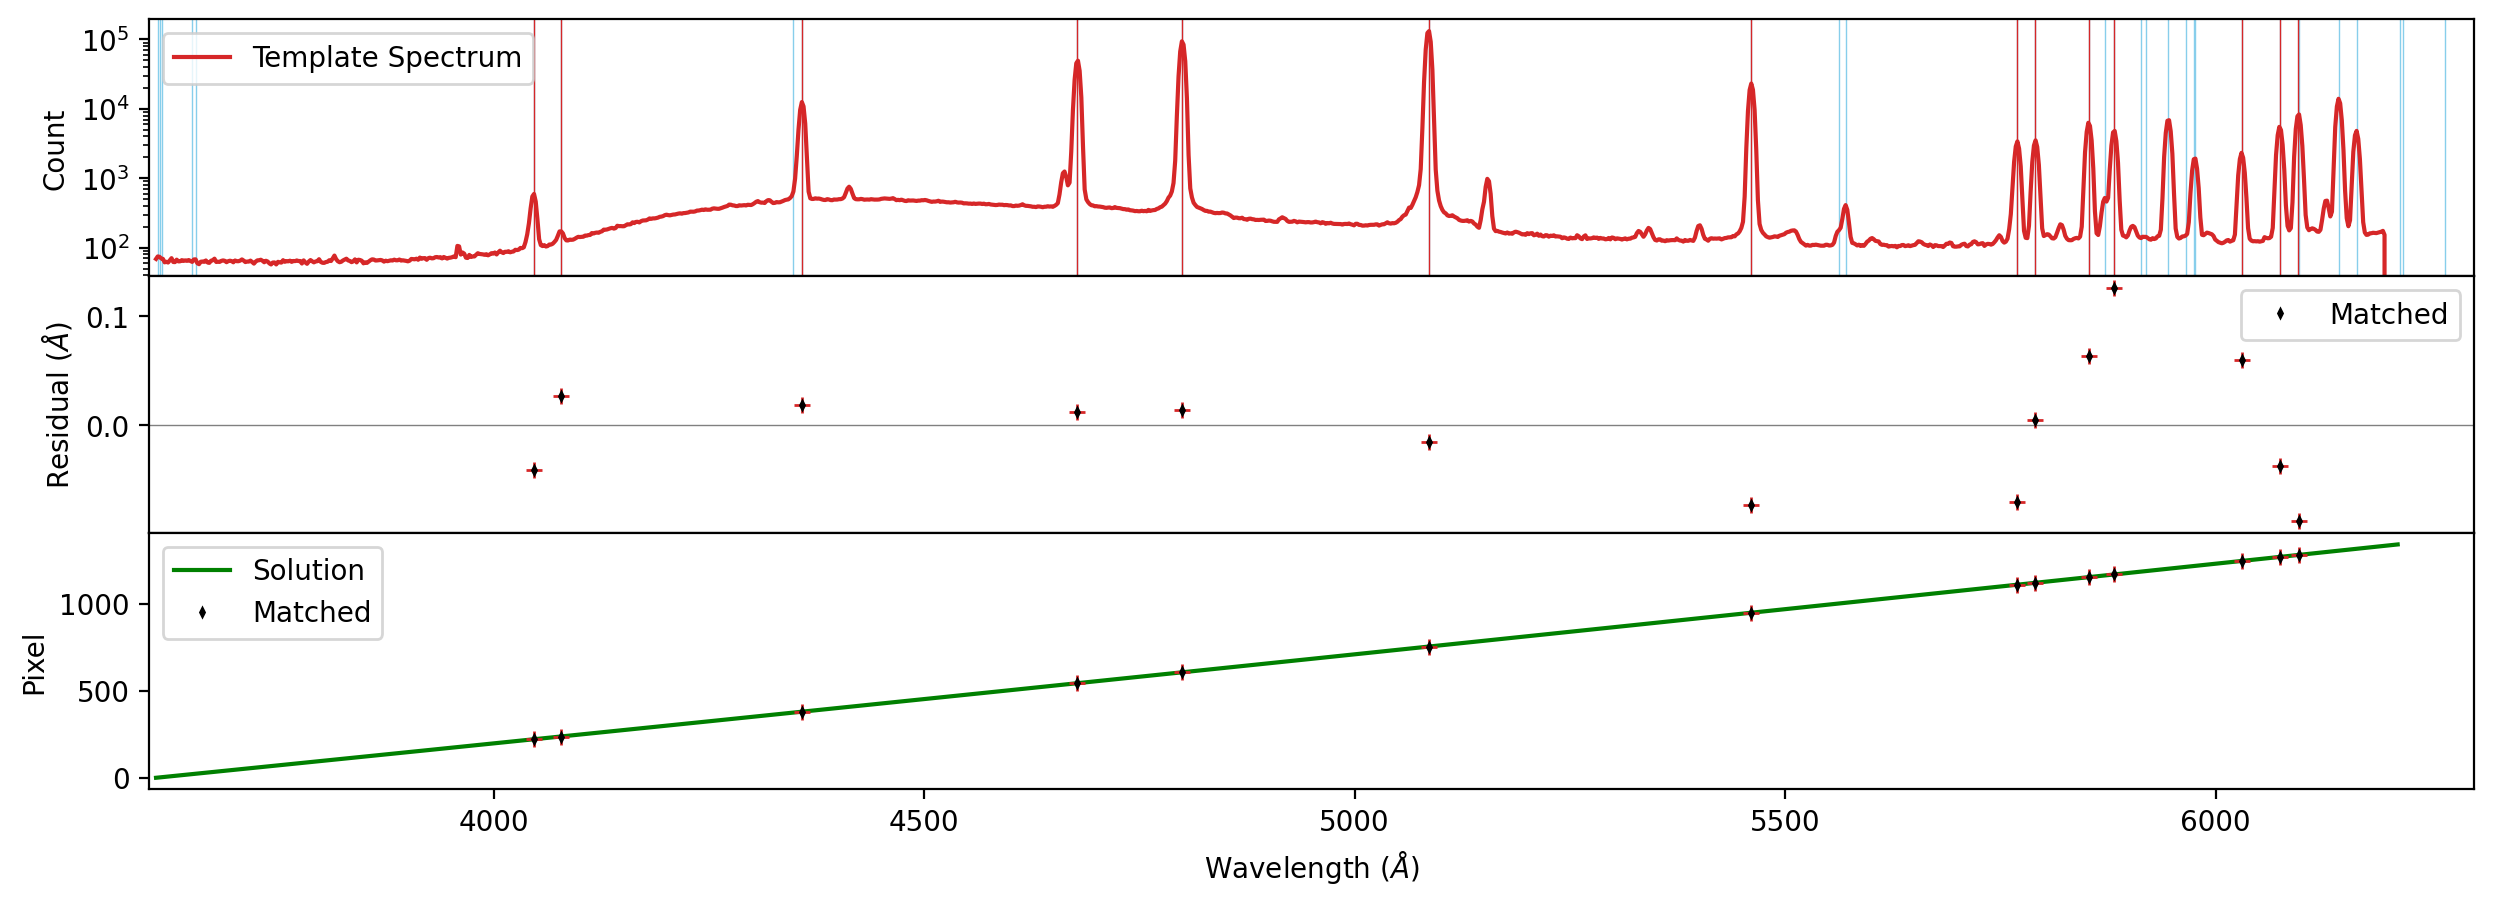

In [29]:
from kspecdr.wavecal.arc_io import read_arc_file

wavetemp = np.polyval(coeffs, np.arange(1340))

xlim = [3600, 6300]

fig, axes = plt.subplots(3, 1, figsize=(15, 5), sharex=True)
ax = axes[0]
# ax.plot(wave, hgarnekrcd_f8, label="Hg(Ar)NeKrCd FIB8", c="k")
# ax.plot(wavetemp, tempspec["flux"], label="Template Spectrum", c="tab:blue")
ax.plot(calispec["wave"], calispec["flux"], label="Template Spectrum", c="tab:red")

nx = 2
xvec = np.array(xlim)
wlist, ilist, labels, nlist = read_arc_file(nx, xvec, "HgArNeKrCd", arc_dir=WD/"data"/"arc_tables")
for i in range(len(wlist)):
    ax.axvline(wlist[i], color="skyblue", lw=0.5, zorder=0)

y_pts_inv = np.polyval(coeffs, x_pts)
for i in range(len(y_pts_inv)):
    ax.axvline(y_pts_inv[i], color="tab:red", lw=0.5, zorder=0)

ax.legend()
ax.set_yscale("log")
ax.set_xlim(xlim)
# ax.set_ylim(-1e4, 7e4)
ax.set_ylabel("Count")

ax = axes[1]
ax.plot(y_pts, residuals, c="tab:red", ls="", marker="+")

ax.plot(y_pts[~outliers], residuals[~outliers], c="k", ls="", marker="d", ms=2, label="Matched")
ax.legend()
ax.axhline(0, c="gray", lw=0.5, zorder=0)
ax.set_ylabel(r"Residual ($\AA$)")

ax = axes[2]
xx = np.arange(1340)
yy = np.polyval(coeffs, xx)
ax.plot(yy, xx, label="Solution", c="green")

ax.plot(y_pts, x_pts, c="tab:red", ls="", marker="+")
ax.plot(y_pts[~outliers], x_pts[~outliers], c="k", ls="", marker="d", ms=2, label="Matched")
ax.legend()
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel("Pixel")
ax.set_xlim(xlim)

ax.legend()

# for ax in axes:
#     # minor ticks direction in
#     ax.minorticks_on()
#     ax.tick_params(which="both", direction="in")
#     ax.tick_params(which="major", length=6)
#     ax.tick_params(which="minor", length=3)

fig.subplots_adjust(hspace=0.0)
